# ACCESS-NRI 2026 -- CMWG Workshop 
# Cryosphere Community Datapool Tools (ccdtools)

This notebook provides an example of the **ACCESS Cryosphere Community Datapool Tools (ccdtools)** and demonstrates how to discover and load datasets relevant to ice sheet modelling. This notebook is designed to be executed on the [NCI _Gadi_ supercomputer](https://opus.nci.org.au/spaces/Help/pages/90308778/0.+Welcome+to+Gadi#id-0.WelcometoGadi-Overview).

Interacting with the ccdtools leverages the `ccdtools.catalog.DataCatalog` class to initialise and interrogate the datapool catalogue.

<div class="alert alert-block alert-info">
<b>AIM:</b> This notebook provides an example of how the <b>Cryosphere Datapool</b> may be used to discover datasets relevant to ice sheet modelling.
</div>

In [1]:
## Load required modules
import ccdtools
import matplotlib.pyplot as plt

## 1 - Initialise and interrogate the datapool catalogue

The ccdtools DataCatalog provides access to datasets stored across Gadi. We can initialise the catalogue and view all available datasets.

In [ ]:
# Initialise the datapool catalogue.
## NOTE: To build a catalog on your local machine, parse a custom YAML file to ccdtools.catalog.DataCatalog(yaml_path = "<PATH_TO_YAML_FILE>").
catalog = ccdtools.catalog.DataCatalog()

# List all datasets within the catalog.
## NOTE: A raw pandas.DataFrame can be returned using catalog.datasets
catalog

,dataset,display_name,description,tags,version,subdataset,path,full_path,extension,skip_lines,no_data_value,ignore_dirs,ignore_files,loader,resolutions,static_patterns,doi
0,measures_bedmachine_antarctica,BedMachine Antarctica,High-resolution bed topography and ice thickne...,"[antarctica, bed topography, ice thickness, su...",v1,None,/g/data/av17/access-nri/cryosphere-data-pool/e...,/g/data/av17/access-nri/cryosphere-data-pool/e...,nc,0,NaN,[],[],default,None,[],10.5067/C2GFER6PTOS4
1,measures_bedmachine_antarctica,BedMachine Antarctica,High-resolution bed topography and ice thickne...,"[antarctica, bed topography, ice thickness, su...",v2,None,/g/data/av17/access-nri/cryosphere-data-pool/e...,/g/data/av17/access-nri/cryosphere-data-pool/e...,nc,0,NaN,[],[],default,None,[],10.5067/E1QL9HFQ7A8M
2,measures_bedmachine_antarctica,BedMachine Antarctica,High-resolution bed topography and ice thickne...,"[antarctica, bed topography, ice thickness, su...",v3,None,/g/data/av17/access-nri/cryosphere-data-pool/e...,/g/data/av17/access-nri/cryosphere-data-pool/e...,nc,0,NaN,[],[],default,None,[],10.5067/FPSU0V1MWUB6
3,bedmap,Bedmap,"Gridded, geospatial, and point datasets of Ant...","[antarctica, bed topography, ice thickness, su...",v1,geospatial,/g/data/av17/access-nri/cryosphere-data-pool/e...,/g/data/av17/access-nri/cryosphere-data-pool/e...,gpkg,0,-9999.0,[],[],default,None,[],10.5285/925ac4ec-2a9d-461a-bfaa-6314eb0888c8
4,bedmap,Bedmap,"Gridded, geospatial, and point datasets of Ant...","[antarctica, bed topography, ice thickness, su...",v1,points,/g/data/av17/access-nri/cryosphere-data-pool/e...,/g/data/av17/access-nri/cryosphere-data-pool/e...,csv,18,-9999.0,[],[],default,None,[],10.5285/f64815ec-4077-4432-9f55-0ce230f46029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,measures_its_live_regional_glacier_and_ice_she...,ITS_LIVE Regional Glacier and Ice Sheet Surfac...,ITS_LIVE regional glacier and ice sheet surfac...,"[antarctica, greenland, ice velocity]",v2,RGI17A,/g/data/av17/access-nri/cryosphere-data-pool/i...,/g/data/av17/access-nri/cryosphere-data-pool/i...,nc,0,NaN,[],[],measures_velocity,None,[_2014-2022_],10.5067/JQ6337239C96
61,measures_its_live_regional_glacier_and_ice_she...,ITS_LIVE Regional Glacier and Ice Sheet Surfac...,ITS_LIVE regional glacier and ice sheet surfac...,"[antarctica, greenland, ice velocity]",v2,RGI18A,/g/data/av17/access-nri/cryosphere-data-pool/i...,/g/data/av17/access-nri/cryosphere-data-pool/i...,nc,0,NaN,[],[],measures_velocity,None,[_2014-2022_],10.5067/JQ6337239C96
62,measures_its_live_regional_glacier_and_ice_she...,ITS_LIVE Regional Glacier and Ice Sheet Surfac...,ITS_LIVE regional glacier and ice sheet surfac...,"[antarctica, greenland, ice velocity]",v2,RGI19A,/g/data/av17/access-nri/cryosphere-data-pool/i...,/g/data/av17/access-nri/cryosphere-data-pool/i...,nc,0,NaN,[],[],measures_velocity,None,[_2014-2022_],10.5067/JQ6337239C96
63,racmo2.3p2_monthly_27km_1979-2022,RACMO2.3p2 Monthly Surface Mass Balance and Cl...,Regional Atmospheric Climate Model (RACMO) ver...,"[antarctica, surface mass balance, climate dat...",v1,None,/g/data/av17/access-nri/cryosphere-data-pool/s...,/g/data/av17/access-nri/cryosphere-data-pool/s...,nc,0,NaN,[],"[Height_latlon_ANT27.nc, TotIS_RACMO_ANT27_IMB...",racmo,None,[],10.5281/zenodo.7845736


### 1.1 - View the catalogue as a dataframe

To view the datasets included in the catalogue as a pandas dataframe, we can access the `datasets` attribute.

In [ ]:
## View the catalogue as a dataframe
catalog.datasets

,filename,path,file_id,frequency,start_date,end_date,variable,variable_long_name,variable_standard_name,variable_cell_methods,variable_units,realm
0,BedMachineAntarctica-v3.nc,/g/data/nf33/access-nri/cryo_data/BedMachine_v...,cryo.fx.BedMachineAntarctica-v3,fx,none,none,['bed' 'dataid' 'errbed' 'firn' 'geoid' 'mask'...,"['bed topography', 'data id', 'bed topography/...","['bedrock_altitude', '', '', '', 'geoid_height...","['', '', '', '', '', '', '', '', '', '', '']","['meters', '', 'meters', 'meters', 'meters', '...",cryo
1,bedmap3.nc,/g/data/nf33/access-nri/cryo_data/BedMap3/bedm...,cryo.fx.bedmap3,fx,none,none,['bed_topography' 'bed_uncertainty' 'ice_thick...,"['Bedrock Elevation', 'Uncertainty in bed elev...","['bedrock_altitude', '', 'land_ice_thickness',...","['', '', '', '', '', '', '', '', '']","['meters', 'meters', 'meters', '1', 'meters', ...",cryo
2,antarctica_ice_velocity_450m_v2.nc,/g/data/nf33/access-nri/cryo_data/MEaSUREs_vel...,cryo.fx.antarctica_ice_velocity_450m_v2,fx,none,none,['CNT' 'ERRX' 'ERRY' 'STDX' 'STDY' 'VX' 'VY' '...,"['Cnt velocity', 'Err velocity in x direction'...","['cnt_ice_velocity', 'err_ice_x_velocity', 'er...","['', '', '', '', '', '', '', '', '', '', '']","['Count', 'meter/year', 'meter/year', 'meter/y...",cryo


## 2 - Search the catalogue

Various functions exist to allow users to interrogate the data catalogue:
- `search()` - Search the data pool for a given keyword. This searches the `dataset`, `display_name`, and `tags` fields.
- `help()` - Retrieve a summary of dataset-specific information for a given dataset.
- `available_versions()` - Retrieve a list of available versions for a given dataset.
- `available_subdatasets()` - Retrieve a list of available subdatasets for a given dataset.
- `available_resolutions()` - Retrieve a list of available resolutions for a given dataset.

### 2.1 - Keyword searching

Let's search the catalogue to return all datasets that contain keywords related to bed topography of Antarctica.

In [ ]:
## Search the catalogue for datasets related to 'bed'
catalog.search('bed')

,unique
filename,2
path,2
file_id,2
frequency,1
start_date,1
end_date,1
variable,17
variable_long_name,2
variable_standard_name,2
variable_cell_methods,2


We can see that this search returns datasets that have relevant data/variables. We can get more information about a specific dataset using the `help()` function.

In [ ]:
## Get detailed information about a specific dataset
catalog.help('measures_bedmachine_antarctica')

,filename,path,file_id,frequency,start_date,end_date,variable,variable_long_name,variable_standard_name,variable_cell_methods,variable_units,realm
0,BedMachineAntarctica-v3.nc,/g/data/nf33/access-nri/cryo_data/BedMachine_v...,cryo.fx.BedMachineAntarctica-v3,fx,none,none,['bed' 'dataid' 'errbed' 'firn' 'geoid' 'mask'...,"['bed topography', 'data id', 'bed topography/...","['bedrock_altitude', '', '', '', 'geoid_height...","['', '', '', '', '', '', '', '', '', '', '']","['meters', '', 'meters', 'meters', 'meters', '...",cryo
1,bedmap3.nc,/g/data/nf33/access-nri/cryo_data/BedMap3/bedm...,cryo.fx.bedmap3,fx,none,none,['bed_topography' 'bed_uncertainty' 'ice_thick...,"['Bedrock Elevation', 'Uncertainty in bed elev...","['bedrock_altitude', '', 'land_ice_thickness',...","['', '', '', '', '', '', '', '', '']","['meters', 'meters', 'meters', '1', 'meters', ...",cryo


### 2.2 - Explore available versions and subdatasets

We can explore what versions and subdatasets are available for a given dataset.

In [ ]:
## Find available versions for BedMachine
print("Available versions:", catalog.available_versions('measures_bedmachine_antarctica'))

## Find available subdatasets for bedmap
print("Available subdatasets:", catalog.available_subdatasets('bedmap'))

Loading ITables v2.4.4 from the internet... (need help?)


## 3 - Load a dataset

To load a dataset, we use the `load_dataset()` function. This accepts various keyword arguments, depending on the dataset. At a minimum it requires `dataset_name`. Other arguments include `version`, `subdataset`, and `resolution`. Let's load the BedMachine v3 bed topography.

In [ ]:
## Load the BedMachine Antarctica dataset (version 3)
bed = catalog.load_dataset('measures_bedmachine_antarctica', version = 'v3')

## View the dataset
bed

/home/565/lb9857/.local/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


<xarray.Dataset> Size: 711MB
Dimensions:  (y: 13333, x: 13333)
Coordinates:
    mapping  |S1 1B ...
  * x        (x) int32 53kB -3333000 -3332500 -3332000 ... 3332500 3333000
  * y        (y) int32 53kB 3333000 3332500 3332000 ... -3332500 -3333000
Data variables:
    bed      (y, x) float32 711MB dask.array<chunksize=(1905, 1905), meta=np.ndarray>
Attributes: (12/32)
    Conventions:                              CF-1.7
    Title:                                    BedMachine Antarctica
    Author:                                   Mathieu Morlighem
    version:                                  03-Jun-2022 (v3.4)
    nx:                                       13333.0
    ny:                                       13333.0
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ['bedrock_altitude', '', '', ''...
    intake_esm_attrs:variable_cell_methods:   ['', '', '', '', '', '', '', ''...
    intake_esm_attrs:variable_units:          ['meters', '', 'meters', 'meter...
    intake_esm_attrs:realm:                   cryo
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   cryo.fx.BedMachineAntarctica-v3

Now that we've loaded the bed topography dataset, we can interact with it just like any other `xarray` dataset! Let's coarsen it to reduce the number of points and make plotting faster.

In [ ]:
## Coarsen the dataset to improve rendering times
bed_5km = bed.coarsen(x = 10, y = 10, boundary = 'trim').mean()

## Viewing the dataset shows reduced X/Y dimensions
bed_5km

<xarray.Dataset> Size: 7MB
Dimensions:  (y: 1333, x: 1333)
Coordinates:
    mapping  |S1 1B b''
  * x        (x) float64 11kB -3.331e+06 -3.326e+06 ... 3.324e+06 3.329e+06
  * y        (y) float64 11kB 3.331e+06 3.326e+06 ... -3.324e+06 -3.329e+06
Data variables:
    bed      (y, x) float32 7MB dask.array<chunksize=(190, 190), meta=np.ndarray>
Attributes: (12/32)
    Conventions:                              CF-1.7
    Title:                                    BedMachine Antarctica
    Author:                                   Mathieu Morlighem
    version:                                  03-Jun-2022 (v3.4)
    nx:                                       13333.0
    ny:                                       13333.0
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ['bedrock_altitude', '', '', ''...
    intake_esm_attrs:variable_cell_methods:   ['', '', '', '', '', '', '', ''...
    intake_esm_attrs:variable_units:          ['meters', '', 'meters', 'meter...
    intake_esm_attrs:realm:                   cryo
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   cryo.fx.BedMachineAntarctica-v3

We can plot the dataset just like any other `xarray` dataset!

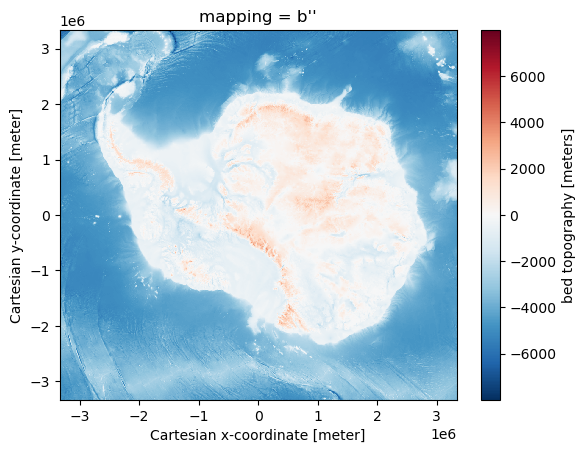

In [9]:
## Create a default xarray plot of the dataset
bed_5km.bed.plot()

## 4. Load and compare multiple datasets

Let's load both BedMachine v3 and Bedmap3 so we can compare different bed topography datasets.

In [ ]:
## Load BedMachine v3
bedmachine = catalog.load_dataset('measures_bedmachine_antarctica', version = 'v3')

## Load Bedmap3
bedmap = catalog.load_dataset('bedmap', version = 'v3')


--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_id'


/home/565/lb9857/.local/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/home/565/lb9857/.local/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


{'cryo.fx.bedmap3': <xarray.Dataset> Size: 5GB
 Dimensions:                 (x: 13334, y: 13334)
 Coordinates:
   * x                       (x) float32 53kB -3.333e+06 -3.333e+06 ... 3.333e+06
   * y                       (y) float32 53kB 3.333e+06 3.333e+06 ... -3.333e+06
 Data variables:
     surface_topography      (y, x) float32 711MB dask.array<chunksize=(13334, 13334), meta=np.ndarray>
     bed_uncertainty         (y, x) float32 711MB dask.array<chunksize=(13334, 13334), meta=np.ndarray>
     bed_topography          (y, x) float32 711MB dask.array<chunksize=(13334, 13334), meta=np.ndarray>
     mask                    (y, x) float32 711MB dask.array<chunksize=(13334, 13334), meta=np.ndarray>
     ice_thickness           (y, x) float32 711MB dask.array<chunksize=(13334, 13334), meta=np.ndarray>
     thickness_survey_count  (y, x) float32 711MB dask.array<chunksize=(13334, 13334), meta=np.ndarray>
     thickness_uncertainty   (y, x) float32 711MB dask.array<chunksize=(13334, 13334)

Let's view the loaded datasets to see what variables are available.

In [ ]:
print("BedMachine variables:", list(bedmachine.data_vars))
print("Bedmap variables:", list(bedmap.data_vars))

dict_keys(['cryo.fx.bedmap3', 'cryo.fx.BedMachineAntarctica-v3'])

Now, let's coarsen both datasets and plot them side-by-side. Remember, we haven't had to download/upload either of these datasets - we've accessed them directly from the catalogue.

In [ ]:
## Coarsen both datasets to reduce rendering times
bedmap_coarse = bedmap.coarsen(x = 10, y = 10, boundary = 'trim').mean()
bedmachine_coarse = bedmachine.coarsen(x = 10, y = 10, boundary = 'trim').mean()

Text(0.5, 1.0, 'BedMachine v3')

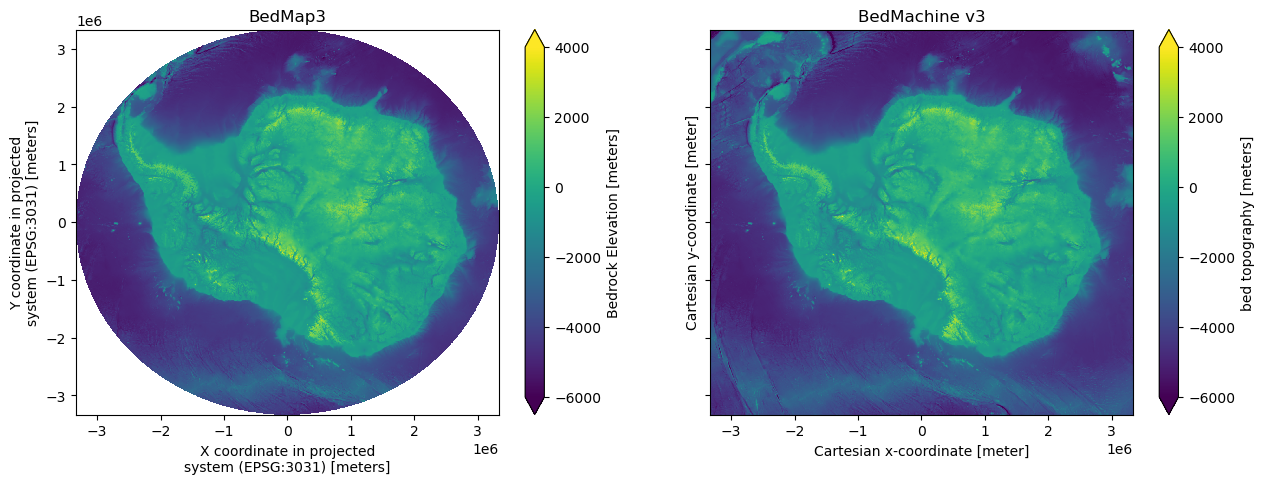

In [ ]:
## Plot BedMachine v3 and BedMap3.
## NOTE: We truncate the extent of the colorbar so they plot with the same colour scale

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5), sharex = True, sharey = True)
bedmap_coarse.bed_topography.plot(ax = ax1, vmax = 4000, vmin = -6000)
bedmachine_coarse.bed.plot(ax = ax2, vmax = 4000, vmin = -6000)

ax1.set_title('BedMap3')
ax2.set_title('BedMachine v3')

BedMachine v3 and BedMap3 are defined on slightly different X/Y coordinates. To allow us to directly compare them, we need to align the coordinates. A quick-and-easy way to do this is to use the `interp_like()` function in `xarray`. Here, we interpolate the BedMap3 data onto the BedMachine v3 coordinates and calculate the difference between the 2 datasets. We then plot the difference between the two datasets.

In [ ]:
## Align the X/Y coordinates by interpolating BedMap3 onto BedMachine coordinates
bedmap_interp = bedmap_coarse.bed_topography.interp_like(bedmachine_coarse.bed)

## Calculate the difference
diff = bedmachine_coarse.bed - bedmap_interp

Text(0.5, 1.0, 'Bed elevation difference between BedMachine v3 and Bedmap3\n (Bedmachine v3 - Bedmap3)')

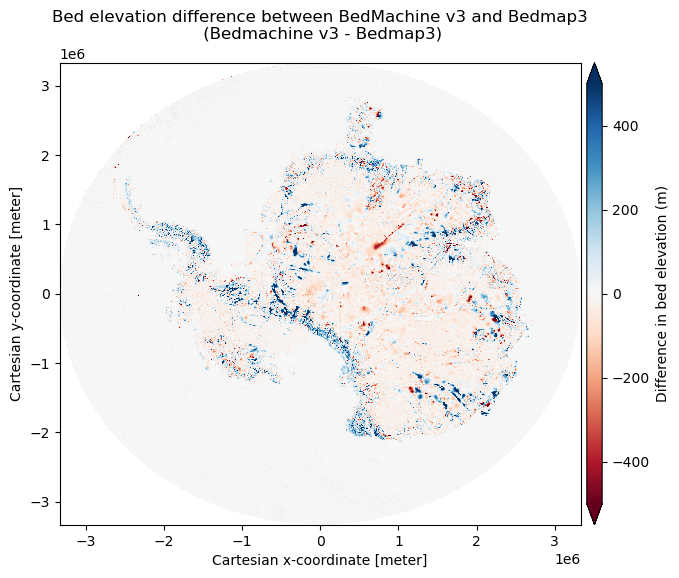

In [15]:
## Plot the difference between BedMachine v3 and BedMap3

fig, ax = plt.subplots(figsize = (8, 6))
diff.plot(ax = ax,
          vmin = -500, 
          vmax = 500,
          cmap = 'RdBu',
          cbar_kwargs = {'label': 'Difference in bed elevation (m)',
                        'aspect': 30,
                        'pad': 0.01})
plt.title('Bed elevation difference between BedMachine v3 and Bedmap3\n (Bedmachine v3 - Bedmap3)')